In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install -U bitsandbytes

In [3]:
import numpy as np
from datasets import load_dataset
import numpy as np
import torch.nn.functional as F
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [4]:
from backtracking_data_sampling import *

## Evaluate Applying Steering Vectors

In [1]:
import pandas as pd
import glob
import os

# Load the df_exploded DataFrame
df_exploded = pd.read_pickle("openr1_math_with_cot_cues.pkl")

# Get the first 1,000 uuids from df_exploded
excluded_uuids = df_exploded['uuid'].iloc[:1000].values
print(excluded_uuids[0])

# Define all directories
dirs = {
    "llama_baseline": "llama_baseline/",
    "abl_10": "abl_10/",
    "abl_19": "abl_19/",
    "abl_25": "abl_25/",
    "abl_all_10": "abl_all_10/",
    "abl_all_19": "abl_all_19/",
    "abl_all_i": "abl_all_i/",
    "abl_all_10_16k": "abl_all_10_16k",
    "baseline_llama_16k": "baseline_llama_16k/",
    # "encouraged_all_10_8k":"encouraged_all_10_8k/",
    "encouraged_all_10_8k_scale.6": "encouraged_all_10_8k_scale.6",
    "encouraged_all_10_8k_scale.8": "encouraged_all_10_8k_scale.8",
    "encouraged_all_10_8k_scale1": "encouraged_all_10_8k_scale1",
    "householder_all_10_8k":"householder_all_10_8k/",
    "orthogonalized_31_all": "orthogonalized_31_all/",
    "orthogonalized_prev_idx_31_all": "orthogonalized_prev_idx_31_all/",
    "succinct_llama_16k": "succinct_llama_16k"
}

# Load DataFrames
dfs = {}
for key, dir_path in dirs.items():
    files = glob.glob(os.path.join(dir_path, "*.parquet"))
    if not files:
        print(f"No files found in {dir_path}")
        continue
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True).drop_duplicates(subset='uuid', keep='first')
    print(len(df), dir_path)
    # Optional renaming for specific columns if needed
    if key == "llama_baseline":
        df = df.rename(columns={"abliterated_all_layers": "llama_baseline"})
    elif key == "abl_all_19":
        df = df.rename(columns={"abliterated_all_layers": "abliterated_all_19"})
    dfs[key] = df[~df['uuid'].isin(excluded_uuids)]

# Get the UUIDs common to all present DataFrames
uuid_sets = [set(df['uuid']) for df in dfs.values()]
common_uuids = set.intersection(*uuid_sets)

# Filter all DataFrames by common UUIDs
dfs = {k: df[df['uuid'].isin(common_uuids)] for k, df in dfs.items()}

# Your final filtered DataFrames are now in the `dfs` dictionary
# For example:
# dfs["llama_baseline"]
# dfs["abl_19"]
# dfs["abl_all_10"]


586fd646-76d6-5070-8c81-9993ab9d8559
1154 llama_baseline/
1203 abl_10/
1154 abl_19/
1104 abl_25/
1203 abl_all_10/
1502 abl_all_19/
1302 abl_all_i/
941 abl_all_10_16k
976 baseline_llama_16k/
966 encouraged_all_10_8k_scale.6
966 encouraged_all_10_8k_scale.8
966 encouraged_all_10_8k_scale1
966 householder_all_10_8k/
807 orthogonalized_31_all/
807 orthogonalized_prev_idx_31_all/
1802 succinct_llama_16k


In [6]:
(dfs.keys())

dict_keys(['llama_baseline', 'abl_10', 'abl_19', 'abl_25', 'abl_all_10', 'abl_all_19', 'abl_all_i', 'abl_all_10_16k', 'baseline_llama_16k', 'encouraged_all_10_8k_scale.6', 'encouraged_all_10_8k_scale.8', 'encouraged_all_10_8k_scale1', 'householder_all_10_8k', 'orthogonalized_31_all', 'orthogonalized_prev_idx_31_all'])

In [7]:
# dfs["abl_19"]

In [2]:
from functools import reduce

# Keep only input_text from llama_baseline, drop from others
for name, df in dfs.items():
    print(len(df), name)
    if name == "llama_baseline":
        # Keep uuid, input_text, and output column
        output_cols = [col for col in df.columns if col not in ['uuid', 'input_text']]
        assert len(output_cols) == 1, f"{name} has multiple output columns: {output_cols}"
        dfs[name] = df[['uuid', 'input_text', output_cols[0]]]
    else:
        # Keep uuid and output column only
        output_cols = [col for col in df.columns if col not in ['uuid', 'input_text']]
        assert len(output_cols) == 1, f"{name} has multiple output columns: {output_cols}"
        dfs[name] = df[['uuid', output_cols[0]]]

# Now merge all DataFrames on 'uuid', starting with llama_baseline
dfs_to_merge = list(dfs.values())
combined_df = reduce(lambda left, right: pd.merge(left, right, on="uuid", how="inner"), dfs_to_merge)

print(f"Combined DataFrame shape: {combined_df.shape}")
combined_df.head()


454 llama_baseline
454 abl_10
454 abl_19
454 abl_25
454 abl_all_10
454 abl_all_19
454 abl_all_i
454 abl_all_10_16k
454 baseline_llama_16k
454 encouraged_all_10_8k_scale.6
454 encouraged_all_10_8k_scale.8
454 encouraged_all_10_8k_scale1
454 householder_all_10_8k
454 orthogonalized_31_all
454 orthogonalized_prev_idx_31_all
454 succinct_llama_16k
Combined DataFrame shape: (454, 18)


,uuid,input_text,llama_baseline,abl_10_output,abl_19_output,abl_25_output,abliterated_all_10,abliterated_all_19,abliterated_all_i,abliterated_all_10_16k,baseline_llama_16k,encouraged_all_10_8k_scale.6,encouraged_all_10_8k_scale.8,encouraged_all_10_8k,householder_all_10_8k,encouraged_all_10_8k_orthogonalized_31_all,orthogonalized_prev_idx_31_all,succinct_llama_16k
0,9d7eb919-103e-51a5-b282-eaec95fdffec,"5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","<｜begin▁of▁sentence｜>5. In $\triangle A B C$, ...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","<｜begin▁of▁sentence｜>5. In $\triangle A B C$, ..."
1,a7d18b0d-9d49-5492-8e5d-2f4f29a48b52,"10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...",<｜begin▁of▁sentence｜>10. Given the set $A=\{x|...,"10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...",<｜begin▁of▁sentence｜>10. Given the set $A=\{x|...
2,fe1e9ae3-45ca-50d0-a66c-6cb1d7b72546,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,<｜begin▁of▁sentence｜>5. Arrange all positive d...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,<｜begin▁of▁sentence｜>5. Arrange all positive d...
3,ba695c33-1565-5685-9634-fbbeb0cd7a4b,"7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...",<｜begin▁of▁sentence｜>7. On the coordinate plan...,"7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...",<｜begin▁of▁sentence｜>7. On the coo

In [9]:
len(combined_df["succinct_llama_16k"][0])

12037

In [12]:
combined_df["llama_baseline"][0]

"5. In $\\triangle A B C$, $\\overrightarrow{A B} \\cdot \\overrightarrow{B C}=3 \\overrightarrow{C A} \\cdot \\overrightarrow{A B}$. Then the maximum value of $\\frac{|\\overrightarrow{A C}|+|\\overrightarrow{A B}|}{|\\overrightarrow{B C}|}$ is ().\n(A) $\\frac{\\sqrt{5}}{2}$\n(B) $\\sqrt{3}$\n(C) 2\n(D) $\\sqrt{5}$\nPlease reason step by step, and put your final answer within \\boxed{}.\nOkay, so I have this problem here about triangle ABC. The condition given is that the dot product of vectors AB and BC is equal to three times the dot product of vectors CA and AB. And I need to find the maximum value of the expression (|AC| + |AB|)/|BC|. The options are A) sqrt(5)/2, B) sqrt(3), C) 2, D) sqrt(5). Hmm, let me try to figure this out step by step.\n\nFirst, let me recall some vector properties. The dot product of two vectors u and v is given by u·v = |u||v|cosθ, where θ is the angle between them. So, maybe I can express the given condition in terms of the sides and angles of the triang

In [4]:
combined_df.columns

Index(['uuid', 'input_text', 'llama_baseline', 'abl_10_output',
       'abl_19_output', 'abl_25_output', 'abliterated_all_10',
       'abliterated_all_19', 'abliterated_all_i', 'abliterated_all_10_16k',
       'baseline_llama_16k', 'encouraged_all_10_8k_scale.6',
       'encouraged_all_10_8k_scale.8', 'encouraged_all_10_8k',
       'householder_all_10_8k', 'encouraged_all_10_8k_orthogonalized_31_all',
       'orthogonalized_prev_idx_31_all', 'succinct_llama_16k'],
      dtype='object')

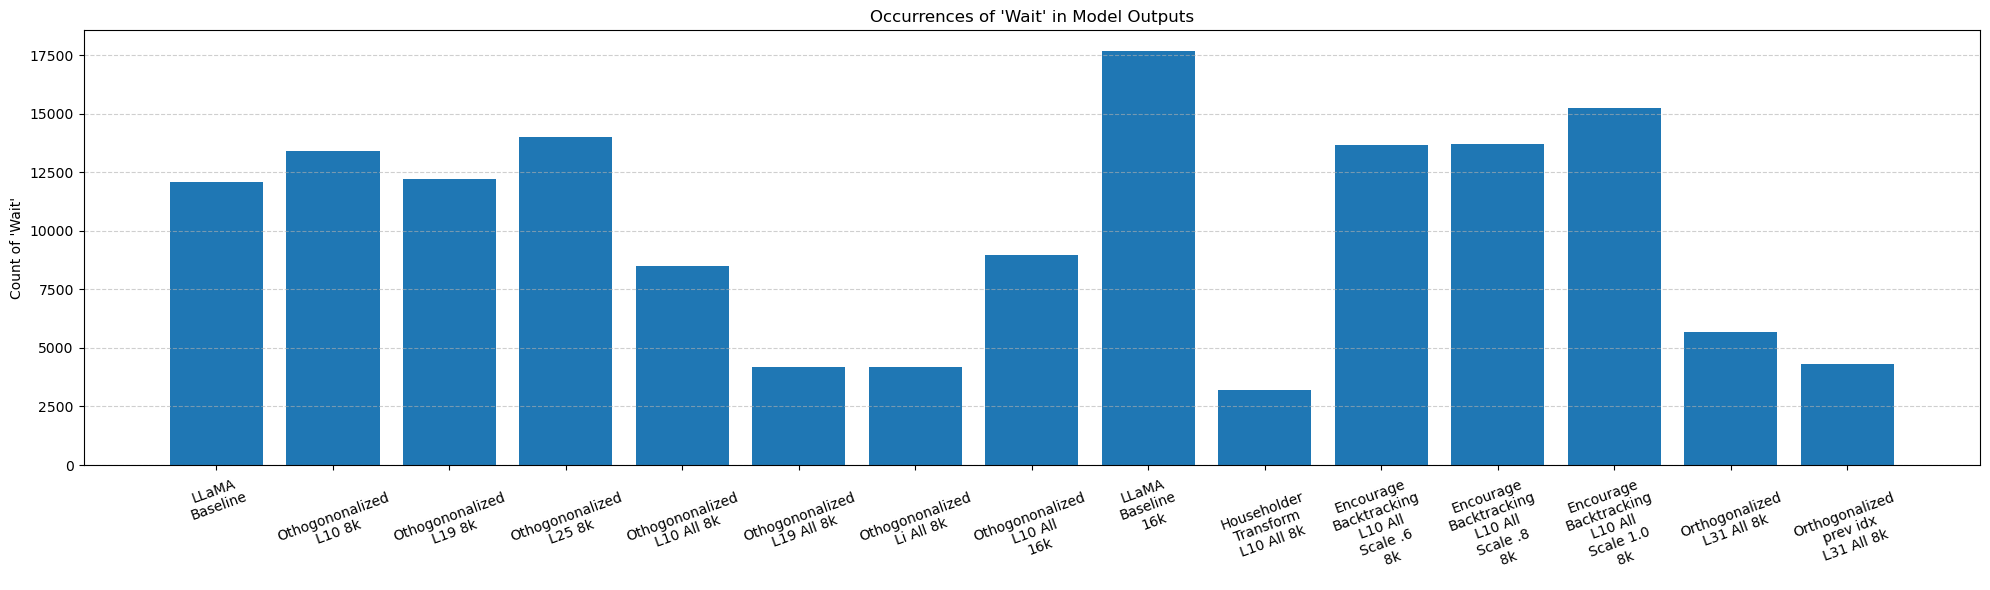

In [10]:
import matplotlib.pyplot as plt

# List of output columns (excluding uuid and input_text)
output_columns = [
    "llama_baseline",
    "abl_10_output",
    "abl_19_output",
    "abl_25_output",
    "abliterated_all_10",
    "abliterated_all_19",
    "abliterated_all_i",
    "abliterated_all_10_16k",
    "baseline_llama_16k",
    "householder_all_10_8k",
    'encouraged_all_10_8k_scale.6',
    'encouraged_all_10_8k_scale.8', 
    "encouraged_all_10_8k",
    'encouraged_all_10_8k_orthogonalized_31_all',
    'orthogonalized_prev_idx_31_all',
]

# Friendly labels for the plot
label_map = {
    "llama_baseline": "LLaMA Baseline",
    "baseline_llama_16k": "LLaMA Baseline 16k",
    "abl_10_output": "Othogononalized L10 8k",
    "abl_19_output": "Othogononalized L19 8k",
    "abl_25_output": "Othogononalized L25 8k",
    "abliterated_all_10": "Othogononalized L10 All 8k",
     "abliterated_all_10_16k" : "Othogononalized L10 All 16k",
    "abliterated_all_19": "Othogononalized L19 All 8k",
    'encouraged_all_10_8k_orthogonalized_31_all': "Orthogonalized L31 All 8k",
    "abliterated_all_i": "Othogononalized Li All 8k",
    "householder_all_10_8k": "Householder Transform L10 All 8k",
    "encouraged_all_10_8k": "Encourage Backtracking L10 All Scale 1.0 8k",
    'encouraged_all_10_8k_scale.6': "Encourage Backtracking L10 All Scale .6 8k",
    'encouraged_all_10_8k_scale.8': "Encourage Backtracking L10 All Scale .8 8k", 
    'orthogonalized_prev_idx_31_all': "Orthogonalized prev idx L31 All 8k",
}

# Helper to insert line break after max 10 characters per line (split on spaces)
def wrap_label(label, max_len=10):
    words = label.split()
    lines = []
    current_line = ""
    for word in words:
        if len(current_line + " " + word) <= max_len:
            current_line = current_line + " " + word if current_line else word
        else:
            lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    return "\n".join(lines)
    

# Count occurrences of "Wait" in each column
wait_counts = {
    col: combined_df[col].str.count(r"\bWait\b").sum()
    for col in output_columns
}

# Plotting
# x_labels = [label_map[col] for col in wait_counts.keys()]
x_labels = [wrap_label(label_map[col]) for col in wait_counts.keys()]
y_values = list(wait_counts.values())

plt.figure(figsize=(20, 6))
plt.bar(x_labels, y_values)
plt.ylabel("Count of 'Wait'")
plt.title("Occurrences of 'Wait' in Model Outputs")
plt.xticks(rotation=20)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [11]:
# Define backtracking cues
# cues = ["Wait", "not sure", "wrong", "Possibly,", "mistake", "Actually", "try again", "rephrase"]
cues = ["but", "wait", "let's", "maybe", "would", "alternatively", "therefore", "which", "check", 
        "each", "compute", "problem", "perhaps", "need", "it's", "that's", "then", "angle", "for", 
        "not", "however", "another", "between", "correct", "might", "both", "where", "there's", "must"]
# Count cue occurrences for each model output column
cue_counts = {cue: [] for cue in cues}

for cue in cues:
    for col in output_columns:
        count = combined_df[col].str.count(rf"\b{cue}\b", flags=re.IGNORECASE).sum()
        cue_counts[cue].append(count)


In [12]:
cue_counts

{'but': [15253,
  17458,
  16472,
  16181,
  12327,
  7644,
  7996,
  15406,
  21917,
  8147,
  16311,
  16720,
  17520,
  9708,
  8016],
 'wait': [13201,
  14813,
  13427,
  15554,
  10480,
  4829,
  4827,
  11020,
  19139,
  3929,
  14997,
  15109,
  16487,
  6727,
  4498],
 "let's": [2677,
  5441,
  2190,
  1920,
  2414,
  2139,
  2243,
  2379,
  3082,
  1344,
  2710,
  2748,
  2867,
  2290,
  1880],
 'maybe': [4466,
  6199,
  6527,
  5610,
  2971,
  1836,
  1866,
  3260,
  5800,
  1489,
  4858,
  4774,
  5438,
  3207,
  2747],
 'would': [2256,
  2060,
  2105,
  2105,
  1612,
  1440,
  1447,
  1736,
  2820,
  926,
  2696,
  2652,
  2839,
  1739,
  1755],
 'alternatively': [2522,
  2839,
  2925,
  2701,
  2066,
  1631,
  1524,
  2887,
  3441,
  511,
  2762,
  2766,
  2970,
  1247,
  1565],
 'therefore': [4313,
  3647,
  3436,
  3671,
  3695,
  3100,
  3198,
  5358,
  6257,
  1166,
  5090,
  5208,
  5385,
  2127,
  3338],
 'which': [8581,
  9517,
  8713,
  9199,
  7138,
  5684,
  5271

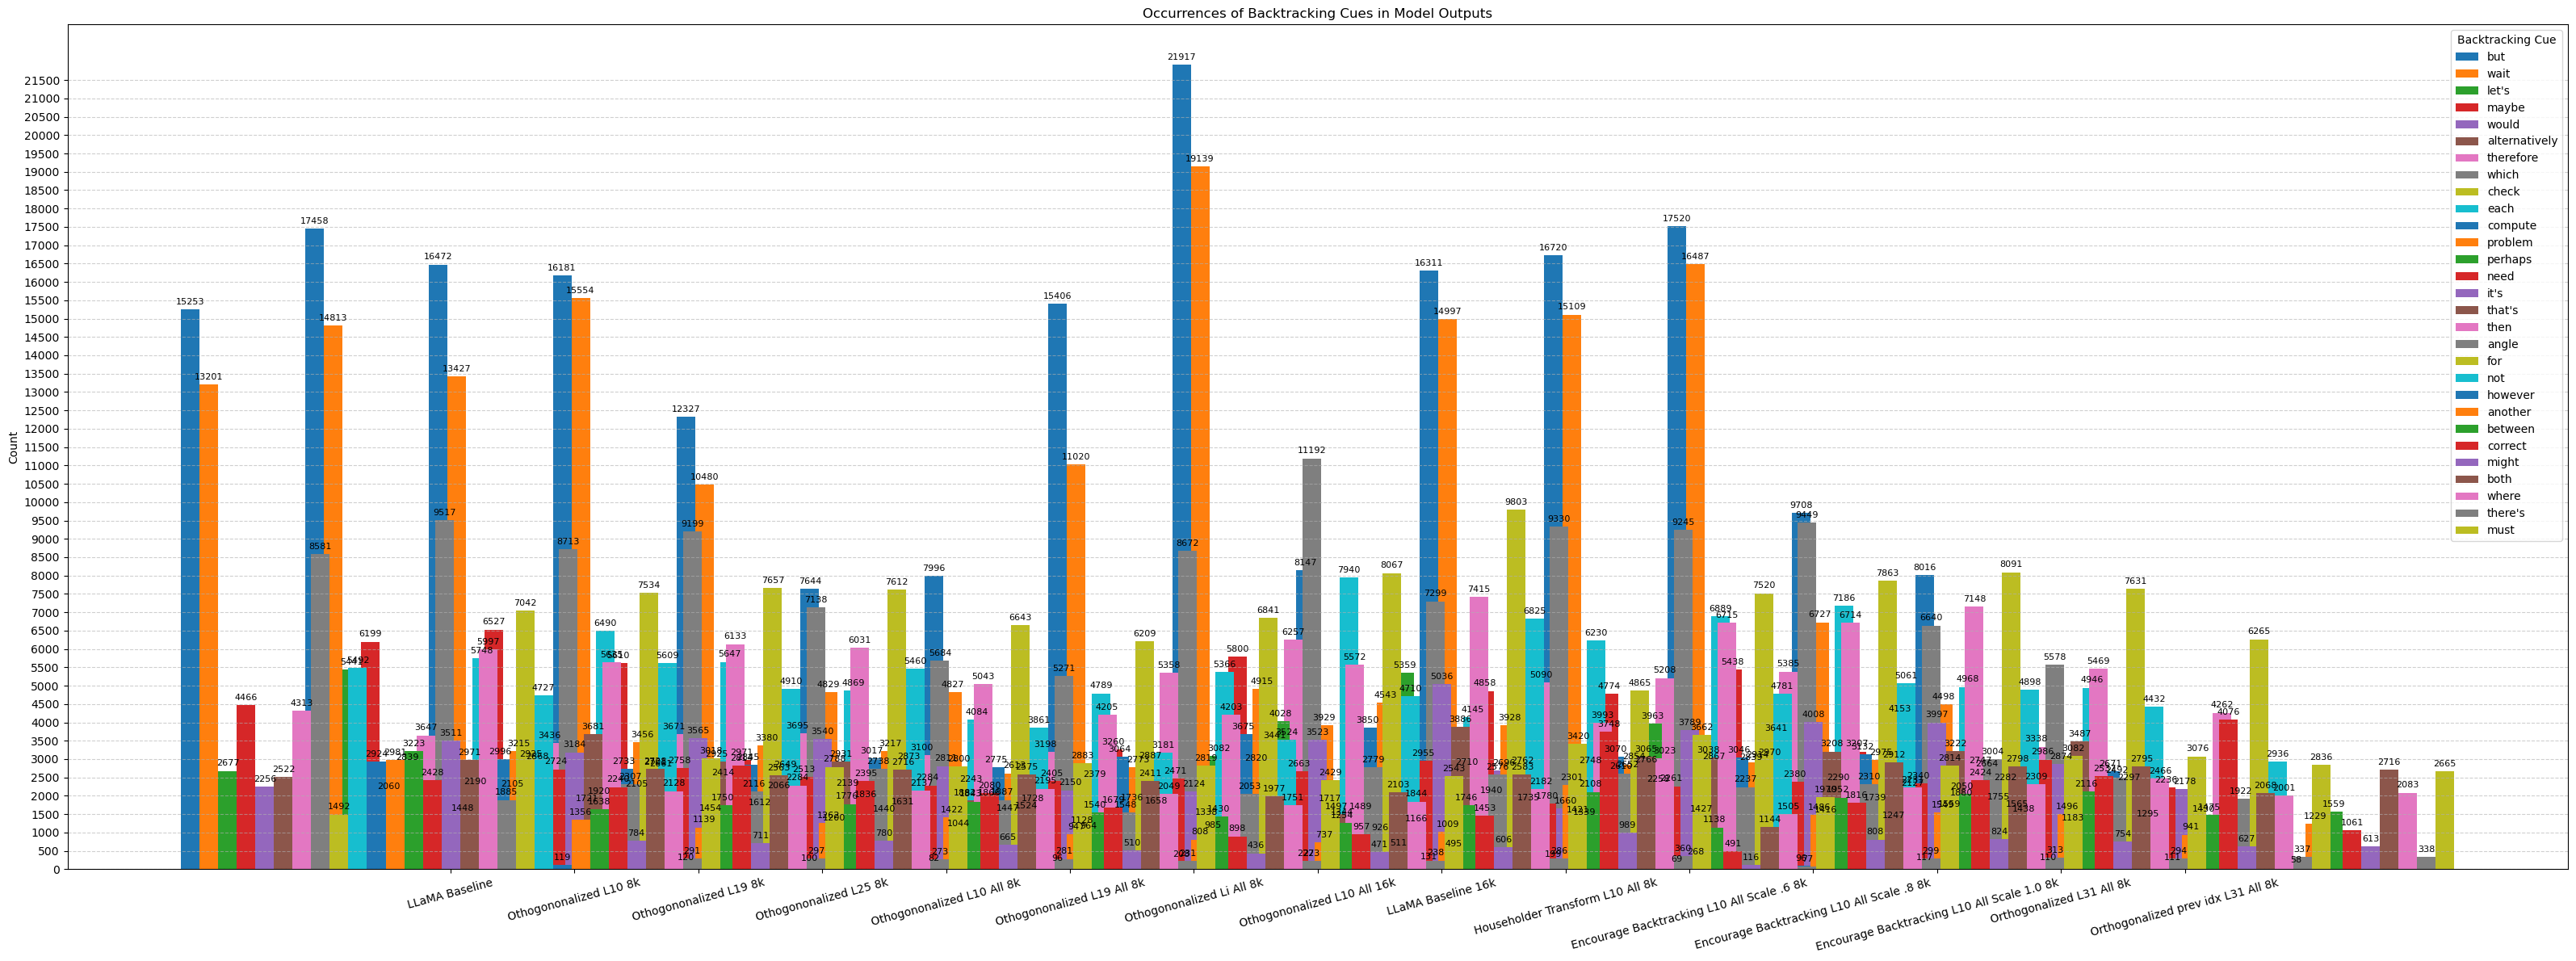

In [13]:
# Clean output columns by removing the input_text prefix
for col in output_columns:
    clean_col = f"{col}_clean"
    combined_df[clean_col] = combined_df.apply(
        lambda row: row[col].replace(str(row["input_text"]), "").strip()
        if isinstance(row[col], str) and isinstance(row["input_text"], str)
        else row[col],
        axis=1
    )

# Plot grouped bar chart
x = np.arange(len(output_columns))  # model positions
width = 0.15  # width of each bar
fig, ax = plt.subplots(figsize=(32, 12))

# Plot bars and add text annotations
for i, cue in enumerate(cues):
    bars = ax.bar(x + i * width, cue_counts[cue], width, label=cue)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=8, rotation=0)

# for i, cue in enumerate(cues):
#     ax.bar(x + i * width, cue_counts[cue], width, label=cue)
# Set x-axis labels and title
ax.set_ylabel("Count")
ax.set_title("Occurrences of Backtracking Cues in Model Outputs")
ax.set_xticks(x + width * (len(cues) - 1) / 2)
ax.set_xticklabels([label_map[col] for col in output_columns], rotation=15)

# Increase y-tick granularity
max_val = max(max(v) for v in cue_counts.values())
ax.set_yticks(np.arange(0, max_val + 10, 500))  # or adjust step as needed


ax.legend(title="Backtracking Cue")
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


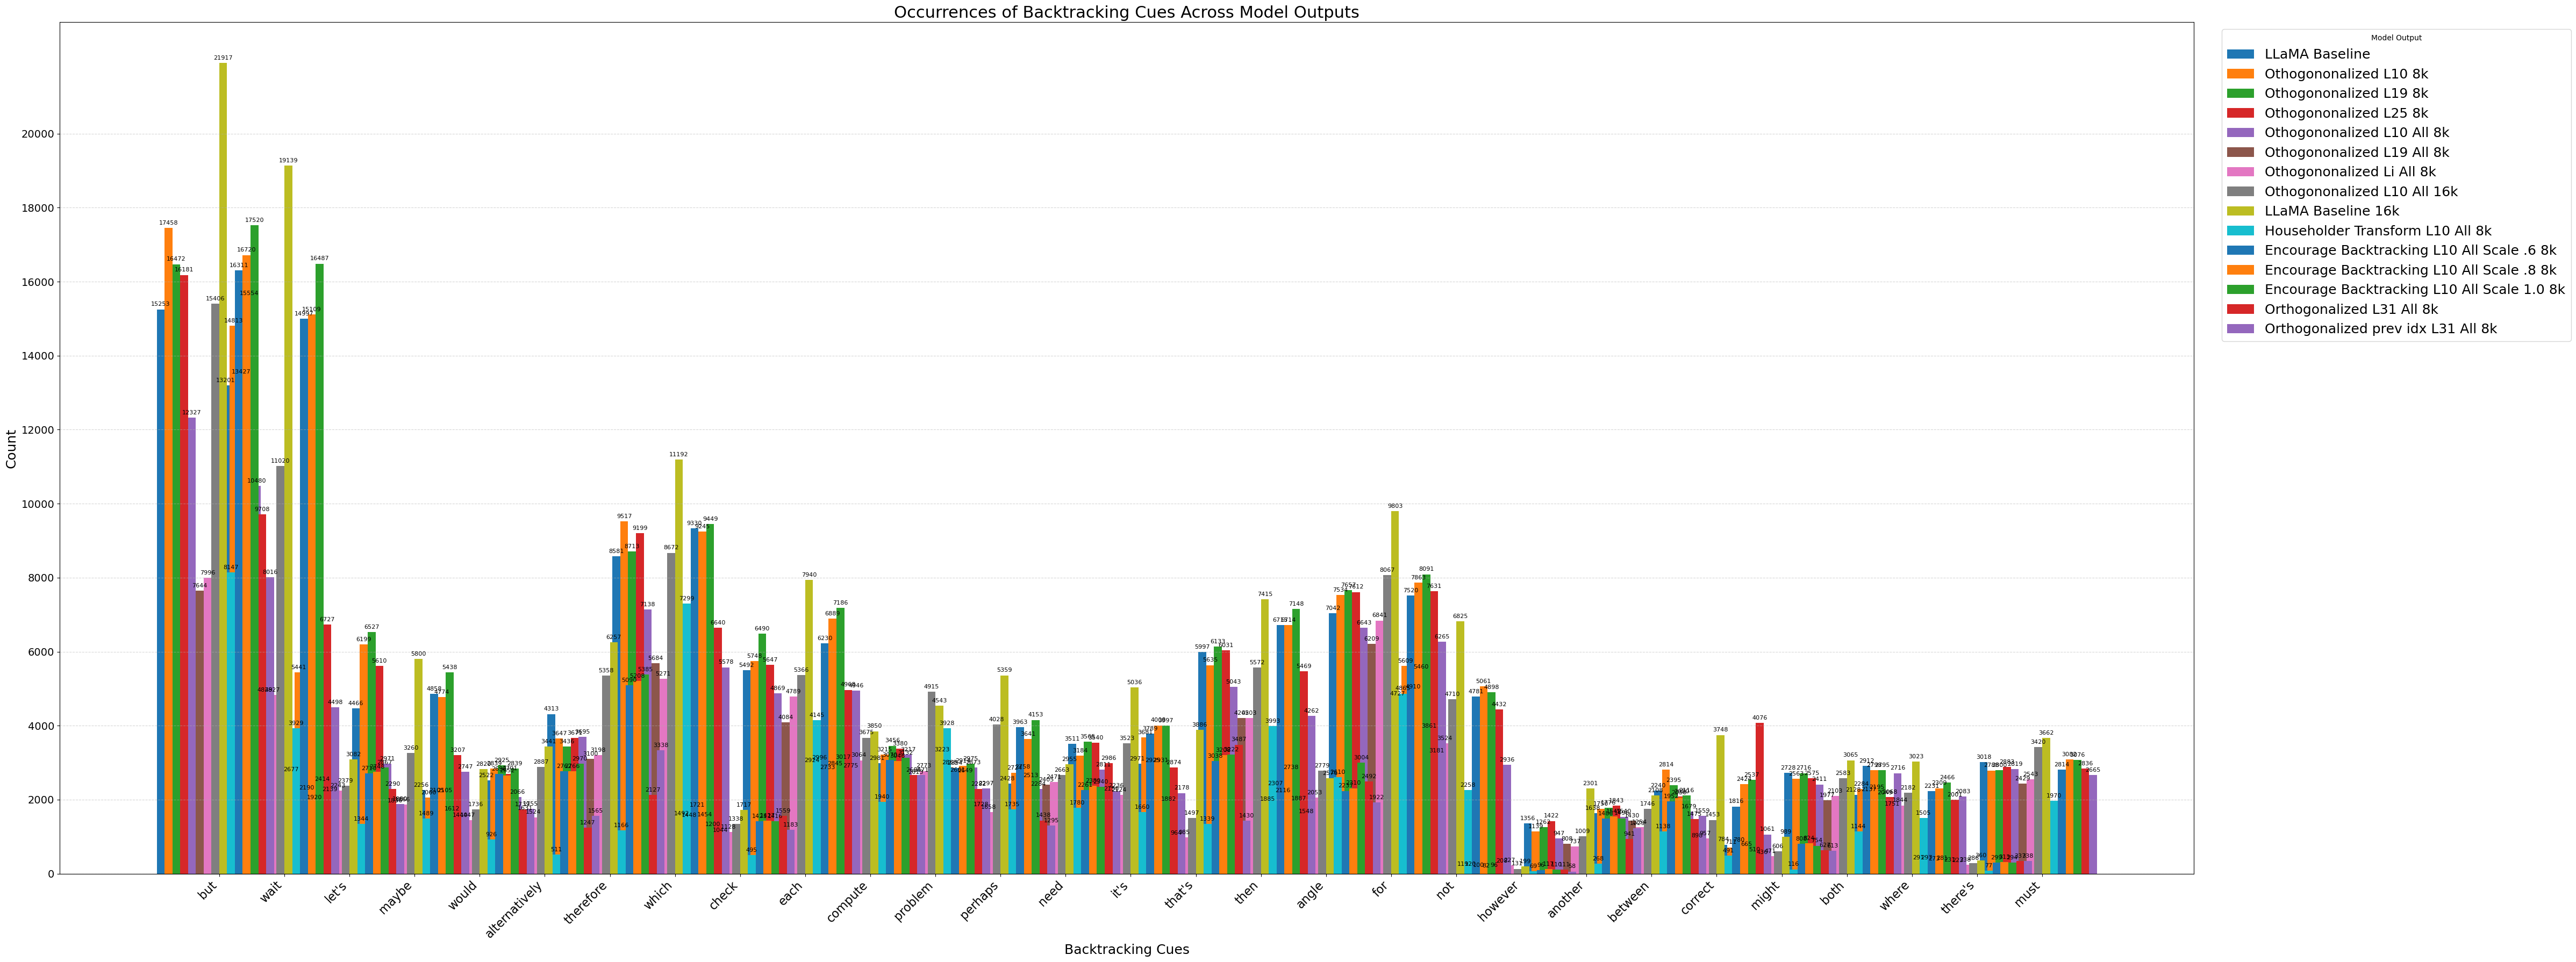

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Flip the plot: cues on x-axis, model names as grouped bars
x = np.arange(len(cues))  # x-axis is now cues
fig, ax = plt.subplots(figsize=(48, 18))

# Bar width
bar_width = 0.12

# Transpose the cue_counts so we can index by output column
model_counts = {col: [cue_counts[cue][i] for cue in cues] for i, col in enumerate(output_columns)}

# Plot grouped bars and add annotations
for i, (col, y_vals) in enumerate(model_counts.items()):
    x_offset = x + (i - len(output_columns) / 2) * bar_width
    bars = ax.bar(x_offset, y_vals, width=bar_width, label=label_map[col])

    # Optional: annotate values on bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=8)

# Axis labeling and style
ax.set_xlabel("Backtracking Cues", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Occurrences of Backtracking Cues Across Model Outputs", fontsize=22)

# Set cue names as x-tick labels
ax.set_xticks(x)
ax.set_xticklabels(cues, rotation=45, ha='right', fontsize=16)
ax.tick_params(axis='y', labelsize=14)

# Y ticks
max_val = max(max(v) for v in cue_counts.values())
ax.set_yticks(np.arange(0, max_val + 10, 2000))

# Legend and layout
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(title="Model Output", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=18)
plt.tight_layout()
plt.savefig("backtracking_cues_hist.png", dpi=300, bbox_inches='tight')  # Save before showing
plt.show()


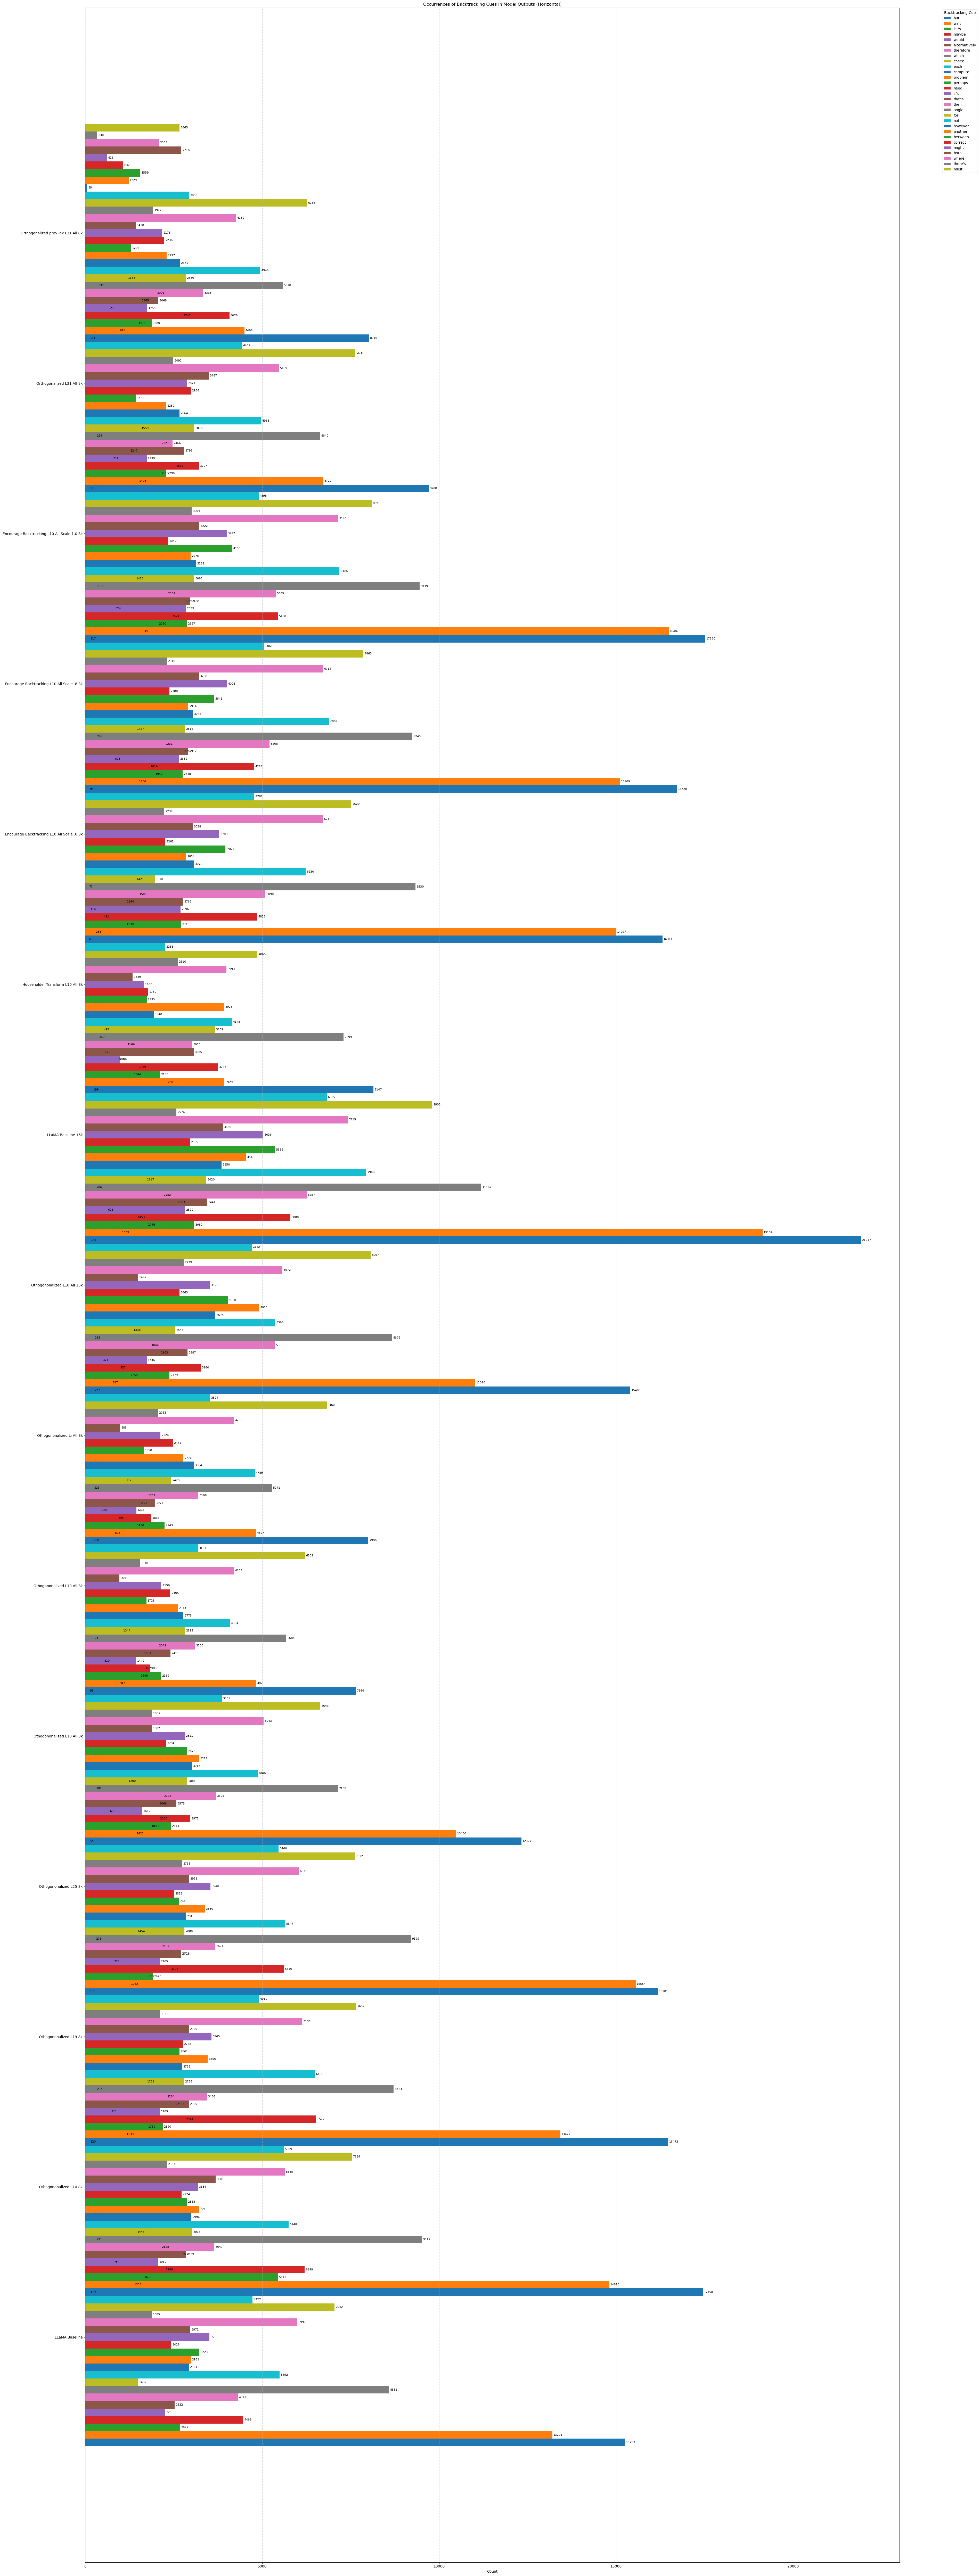

In [15]:
# Transpose to get counts per model
model_names = [label_map[col] for col in output_columns]
counts_per_model = np.array([cue_counts[cue] for cue in cues])  # shape: (num_cues, num_models)



# Plot horizontal grouped bars
y = np.arange(len(model_names))  # y-axis positions for model outputs
bar_height = 0.05
fig, ax = plt.subplots(figsize=(38, 100))

# For each cue, plot horizontal bars shifted vertically
for i, cue in enumerate(cues):
    bars = ax.barh(y + i * bar_height, counts_per_model[i], height=bar_height, label=cue)
    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'{int(width)}',
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(3, 0),  # offset
                    textcoords="offset points",
                    ha='left', va='center',
                    fontsize=8)

# Set axis labels
ax.set_xlabel("Count")
ax.set_title("Occurrences of Backtracking Cues in Model Outputs (Horizontal)")

# Set y-ticks in center of group
ax.set_yticks(y + bar_height * (len(cues) - 1) / 2)
ax.set_yticklabels(model_names)

# Add grid and legend
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
ax.legend(title="Backtracking Cue", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
def extract_first_boxed_and_truncate(text):
    if not isinstance(text, str):
        return None, text

    start = text.find(r'\boxed{')
    if start == -1:
        return None, text  # no boxed expression

    i = start + len(r'\boxed{')
    brace_count = 1
    content_chars = []

    while i < len(text) and brace_count > 0:
        char = text[i]
        if char == '{':
            brace_count += 1
        elif char == '}':
            brace_count -= 1

        if brace_count > 0:
            content_chars.append(char)
        i += 1

    if brace_count == 0:
        boxed_answer = ''.join(content_chars).strip()
        truncated_text = text[:i].strip()
        return boxed_answer, truncated_text
    else:
        return None, text  # malformed box


In [17]:
output_columns

['llama_baseline',
 'abl_10_output',
 'abl_19_output',
 'abl_25_output',
 'abliterated_all_10',
 'abliterated_all_19',
 'abliterated_all_i',
 'abliterated_all_10_16k',
 'baseline_llama_16k',
 'householder_all_10_8k',
 'encouraged_all_10_8k_scale.6',
 'encouraged_all_10_8k_scale.8',
 'encouraged_all_10_8k',
 'encouraged_all_10_8k_orthogonalized_31_all',
 'orthogonalized_prev_idx_31_all']

In [18]:
combined_df

,uuid,input_text,llama_baseline,abl_10_output,abl_19_output,abl_25_output,abliterated_all_10,abliterated_all_19,abliterated_all_i,abliterated_all_10_16k,...,abliterated_all_19_clean,abliterated_all_i_clean,abliterated_all_10_16k_clean,baseline_llama_16k_clean,householder_all_10_8k_clean,encouraged_all_10_8k_scale.6_clean,encouraged_all_10_8k_scale.8_clean,encouraged_all_10_8k_clean,encouraged_all_10_8k_orthogonalized_31_all_clean,orthogonalized_prev_idx_31_all_clean
0,9d7eb919-103e-51a5-b282-eaec95fdffec,"5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...",...,"Okay, so I have this problem about vectors in ...","Alright, so I have this problem here about vec...","Okay, so I have this problem about vectors in ...","Alright, so I've got this geometry problem her...","Okay, so I have this problem here about vector...","Okay, so I have this problem about triangle AB...","Okay, so I have this problem about triangle AB...","Alright, so I have this problem about triangle...","Okay, so I have this problem about a triangle ...","Okay, so I have this problem about triangle AB..."
1,a7d18b0d-9d49-5492-8e5d-2f4f29a48b52,"10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...",...,"Alright, so I have this problem here. Let me r...","Alright, so I have this problem here where I n...","Okay, so I have this problem here: Given the s...","Okay, so I've got this problem here: We have t...","Okay, so I have this problem here: Given set A...","Okay, so I have this problem here: Given set A...","Okay, so I have this problem here: Given set A...","Okay, so I have this problem here where I need...","Okay, so I need to figure out the range of the...","Alright, so I have this problem here. Let me r..."
2,fe1e9ae3-45ca-50d0-a66c-6cb1d7b72546,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,...,"Okay, so I have this problem: I need to arrang...","Okay, so I need to figure out how to arrange a...","Alright, so I have this problem here: I need t...","Okay, so I have this problem where I need to f...","Okay, so I have this problem here: I need to f...","Okay, so I have this problem here: I need to a...","Okay, so I have this problem here: I need to a...","Okay, so I have this problem here where I need...","Okay, so I have this problem where I need to f...","Alright, so I have this problem where I need t..."
3,ba695c33-1565-5685-9634-fbbeb0cd7a4b,"7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ..."

In [19]:
# Apply across all output columns
for col in output_columns:
    clean_col = f"{col}_clean"
    answer_col = f"{col}_answer"

    # Apply and assign both answer and truncated clean output
    combined_df[[answer_col, clean_col]] = combined_df[clean_col].apply(
        lambda x: pd.Series(extract_first_boxed_and_truncate(x))
    )

In [20]:
combined_df

,uuid,input_text,llama_baseline,abl_10_output,abl_19_output,abl_25_output,abliterated_all_10,abliterated_all_19,abliterated_all_i,abliterated_all_10_16k,...,abliterated_all_19_answer,abliterated_all_i_answer,abliterated_all_10_16k_answer,baseline_llama_16k_answer,householder_all_10_8k_answer,encouraged_all_10_8k_scale.6_answer,encouraged_all_10_8k_scale.8_answer,encouraged_all_10_8k_answer,encouraged_all_10_8k_orthogonalized_31_all_answer,orthogonalized_prev_idx_31_all_answer
0,9d7eb919-103e-51a5-b282-eaec95fdffec,"5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...",...,B,B,None,B,None,B,None,B,None,B
1,a7d18b0d-9d49-5492-8e5d-2f4f29a48b52,"10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...",...,"(-\infty, -2]","(-\infty, -2]","(-\infty, 2]","(-\infty, -2]","(-\infty, -2]","(-\infty, 2]","(-\infty, 2)","(-\infty, -2]","(-\infty, -2]","(-\infty, 2]"
2,fe1e9ae3-45ca-50d0-a66c-6cb1d7b72546,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,...,1242060,211815,211755,211495,None,None,None,None,212735,211335
3,ba695c33-1565-5685-9634-fbbeb0cd7a4b,"7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...",...,4,4,4,4,None,None,\dfrac{11}{3},4,None,\dfrac{20}{3}
4,d19006f9-a72a-5f8c-8874-e5be5354b686,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,...,40,\dfrac{200}{7},40,60,40,40,50,50,40,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,31c6743d-8524-5e6d-940a-372bff0c3427,"2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...",...,38,None,71,a = 53,None,None,None,None,53,None
440,1e

In [21]:
combined_df["input_text"][1]

'10. Given the set $A=\\{x|| x \\mid \\leqslant 2, x \\in \\mathbf{R}\\}, B=\\{x \\mid x \\geqslant a\\}$, and $A \\subseteq B$; then the range of the real number $a$ is $\\qquad$ .\nPlease reason step by step, and put your final answer within \\boxed{}.\n'

In [22]:
from datasets import load_dataset

# Load the dataset (this may take a bit of time the first time)
dataset = load_dataset("open-r1/OpenR1-Math-220k", split="train")
openr1_df = dataset.to_pandas()

# Are there duplicated uuids in openr1_df?
print("Duplicates in openr1_df:", openr1_df["uuid"].duplicated().sum())


# Group by uuid and count number of unique answers for each group
inconsistencies = openr1_df.groupby("uuid")["answer"].nunique()

# Filter to only those with more than 1 unique answer
inconsistent_uuids = inconsistencies[inconsistencies > 1]

# Filter to only those with more than 1 unique answer
inconsistent_uuids = inconsistencies[inconsistencies > 1]

print(f"Number of duplicated uuids with inconsistent answers: {len(inconsistent_uuids)}")


Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Duplicates in openr1_df: 722
Number of duplicated uuids with inconsistent answers: 9


In [23]:
# Drop UUIDs with inconsistent answers
uuid_counts = openr1_df.groupby("uuid")["answer"].nunique()
consistent_uuids = uuid_counts[uuid_counts == 1].index
openr1_df_clean = openr1_df[openr1_df["uuid"].isin(consistent_uuids)].drop_duplicates(subset="uuid")

# Join the 'answer' column from openr1_df_clean into combined_df
combined_df = combined_df.merge(
    openr1_df_clean[["uuid", "answer"]],
    on="uuid",
    how="left"
)

In [24]:
combined_df

,uuid,input_text,llama_baseline,abl_10_output,abl_19_output,abl_25_output,abliterated_all_10,abliterated_all_19,abliterated_all_i,abliterated_all_10_16k,...,abliterated_all_i_answer,abliterated_all_10_16k_answer,baseline_llama_16k_answer,householder_all_10_8k_answer,encouraged_all_10_8k_scale.6_answer,encouraged_all_10_8k_scale.8_answer,encouraged_all_10_8k_answer,encouraged_all_10_8k_orthogonalized_31_all_answer,orthogonalized_prev_idx_31_all_answer,answer
0,9d7eb919-103e-51a5-b282-eaec95fdffec,"5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...",...,B,None,B,None,B,None,B,None,B,B
1,a7d18b0d-9d49-5492-8e5d-2f4f29a48b52,"10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...",...,"(-\infty, -2]","(-\infty, 2]","(-\infty, -2]","(-\infty, -2]","(-\infty, 2]","(-\infty, 2)","(-\infty, -2]","(-\infty, -2]","(-\infty, 2]",\leqslant-2
2,fe1e9ae3-45ca-50d0-a66c-6cb1d7b72546,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,...,211815,211755,211495,None,None,None,None,212735,211335,211335
3,ba695c33-1565-5685-9634-fbbeb0cd7a4b,"7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...",...,4,4,4,None,None,\dfrac{11}{3},4,None,\dfrac{20}{3},4
4,d19006f9-a72a-5f8c-8874-e5be5354b686,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,...,\dfrac{200}{7},40,60,40,40,50,50,40,100,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,31c6743d-8524-5e6d-940a-372bff0c3427,"2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...",...,None,71,a = 53,None,None,None,None,53,None,"(=53,b=53,=19),(=19,b=19,=53)"
4

In [29]:
len(combined_df)

444

In [26]:
combined_df.to_parquet("bedrock_sample4.parquet", index=False)

In [28]:
combined_df

,uuid,input_text,llama_baseline,abl_10_output,abl_19_output,abl_25_output,abliterated_all_10,abliterated_all_19,abliterated_all_i,abliterated_all_10_16k,...,abliterated_all_i_answer,abliterated_all_10_16k_answer,baseline_llama_16k_answer,householder_all_10_8k_answer,encouraged_all_10_8k_scale.6_answer,encouraged_all_10_8k_scale.8_answer,encouraged_all_10_8k_answer,encouraged_all_10_8k_orthogonalized_31_all_answer,orthogonalized_prev_idx_31_all_answer,answer
0,9d7eb919-103e-51a5-b282-eaec95fdffec,"5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...",...,B,None,B,None,B,None,B,None,B,B
1,a7d18b0d-9d49-5492-8e5d-2f4f29a48b52,"10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...",...,"(-\infty, -2]","(-\infty, 2]","(-\infty, -2]","(-\infty, -2]","(-\infty, 2]","(-\infty, 2)","(-\infty, -2]","(-\infty, -2]","(-\infty, 2]",\leqslant-2
2,fe1e9ae3-45ca-50d0-a66c-6cb1d7b72546,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,...,211815,211755,211495,None,None,None,None,212735,211335,211335
3,ba695c33-1565-5685-9634-fbbeb0cd7a4b,"7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...",...,4,4,4,None,None,\dfrac{11}{3},4,None,\dfrac{20}{3},4
4,d19006f9-a72a-5f8c-8874-e5be5354b686,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,8. Variant 1.\n\nOn side $A B$ of parallelogra...,...,\dfrac{200}{7},40,60,40,40,50,50,40,100,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,31c6743d-8524-5e6d-940a-372bff0c3427,"2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...","2. Find the real numbers $a, b, c>0$ if\n\n$$\...",...,None,71,a = 53,None,None,None,None,53,None,"(=53,b=53,=19),(=19,b=19,=53)"
4

In [32]:
combined_df.columns

Index(['uuid', 'input_text', 'llama_baseline', 'abl_10_output',
       'abl_19_output', 'abl_25_output', 'abliterated_all_10',
       'abliterated_all_19', 'abliterated_all_i', 'abliterated_all_10_16k',
       'baseline_llama_16k', 'llama_baseline_clean', 'abl_10_output_clean',
       'abl_19_output_clean', 'abl_25_output_clean',
       'abliterated_all_10_clean', 'abliterated_all_19_clean',
       'abliterated_all_i_clean', 'abliterated_all_10_16k_clean',
       'baseline_llama_16k_clean', 'llama_baseline_answer',
       'abl_10_output_answer', 'abl_19_output_answer', 'abl_25_output_answer',
       'abliterated_all_10_answer', 'abliterated_all_19_answer',
       'abliterated_all_i_answer', 'abliterated_all_10_16k_answer',
       'baseline_llama_16k_answer', 'answer'],
      dtype='object')

### Example Steering Vector

In [ ]:
# Define the input text
input_text = """
## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.
\nPlease reason step by step, and put your final answer within \\boxed{}.\n"""


steering_vectors = torch.load("steering_vectors_Wait.pt")
layer_index = selected_layers[0]
# Baseline (no steering)
baseline_output = generate_text(model, tokenizer, input_text)

# Steering Towards Backtracking
backtracking_output = generate_text(model, tokenizer, input_text, 
                                   steering_vector=steering_vectors[5], scale=1.0)

# Steering Away from Backtracking
anti_backtracking_output = generate_text(model, tokenizer, input_text, 
                                        steering_vector=-steering_vectors[5], scale=1.0)

print("=== Baseline ===")
print(baseline_output)
print("\n=== Steering Towards Backtracking ===")
print(backtracking_output)
print("\n=== Steering Away from Backtracking ===")
print(anti_backtracking_output)


Before and after steering, measure how the model assigns probabilities to a cue like "Wait".


In [ ]:
def get_token_probability(model, tokenizer, input_text, target_token):
    """
    Computes probability of a target token appearing in the model's predictions.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model(**inputs)
        logits = output.logits  # Shape: (batch_size, seq_length, vocab_size)

    # Get the last token's logits
    last_token_logits = logits[0, -1, :]  # Shape: (vocab_size,)

    # Convert logits to probabilities
    probs = torch.nn.functional.softmax(last_token_logits, dim=0)

    # Get probability of target token
    target_token_id = tokenizer.convert_tokens_to_ids(target_token)
    target_token_prob = probs[target_token_id].item()

    return target_token_prob

# Compute probabilities for "Wait" before and after steering
baseline_prob = get_token_probability(model, tokenizer, baseline_output, "Wait")
backtracking_prob = get_token_probability(model, tokenizer, backtracking_output, "Wait")
anti_backtracking_prob = get_token_probability(model, tokenizer, anti_backtracking_output, "Wait")

print(f"Baseline 'Wait' Probability: {baseline_prob:.6f}")
print(f"Backtracking 'Wait' Probability: {backtracking_prob:.6f}")
print(f"Anti-Backtracking 'Wait' Probability: {anti_backtracking_prob:.6f}")


Sentence Completion Differences
Look for differences in generated sentences
Does the model change its prediction after applying the steering vector?

To compare token probability distributions before and after steering

In [ ]:
def get_top_k_probabilities(model, tokenizer, input_text, top_k=5):
    """
    Computes the top-k token probabilities after the last token.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model(**inputs)
        logits = output.logits[0, -1, :]  # Last token logits

    # Convert logits to probabilities
    probs = torch.nn.functional.softmax(logits, dim=0)

    # Get the top-k predictions
    top_k_probs, top_k_indices = torch.topk(probs, top_k)

    # Convert indices to tokens
    top_k_tokens = tokenizer.convert_ids_to_tokens(top_k_indices.tolist())

    return list(zip(top_k_tokens, top_k_probs.tolist()))

# Measure before and after steering
baseline_probs = get_top_k_probabilities(model, tokenizer, baseline_output)
backtracking_probs = get_top_k_probabilities(model, tokenizer, backtracking_output)
anti_backtracking_probs = get_top_k_probabilities(model, tokenizer, anti_backtracking_output)

print("Baseline Token Probabilities:", baseline_probs)
print("Backtracking Token Probabilities:", backtracking_probs)
print("Anti-Backtracking Token Probabilities:", anti_backtracking_probs)


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------
# 1) Define reasoning cues
# ------------------
reasoning_cues = relevant_cues
# Flatten all token IDs for each cue into one big set
reasoning_token_ids = set()
for cue in reasoning_cues:
    token_ids = tokenizer(cue, add_special_tokens=False).input_ids
    for tid in token_ids:
        reasoning_token_ids.add(tid)

# ------------------
# 2) Tokenize your message
# ------------------
message = df["prefill"][index]   # from your example
inputs = tokenizer(message, return_tensors="pt")
input_ids = inputs["input_ids"].to(model.device)

# We'll measure up to the second-to-last token for prefix
seq_len = input_ids.shape[1]

reasoning_probabilities = []
reasoning_positions = []

# ------------------
# 3) Loop over each prefix
# ------------------
for i in range(seq_len - 1):
    # Slice prefix from token 0..i (inclusive)
    prefix_input_ids = input_ids[:, :i+1]

    # Forward pass to get logits for next token
    with torch.no_grad():
        output = model(prefix_input_ids, use_cache=False)
    
    # output.logits has shape [batch_size, seq_len, vocab_size]
    # Here, seq_len = i+1 for the prefix
    next_token_logits = output.logits[0, -1, :]       # shape: [vocab_size]
    next_token_probs = F.softmax(next_token_logits, dim=-1)

    # Sum the probability for all "reasoning" tokens
    sum_reasoning_prob = next_token_probs[list(reasoning_token_ids)].sum().item()
    reasoning_probabilities.append(sum_reasoning_prob)

    # Check if the *actual* token at i+1 is a reasoning token
    # (the next token in the real sequence is input_ids[0, i+1])
    actual_next_token_id = input_ids[0, i+1].item()
    if actual_next_token_id in reasoning_token_ids:
        reasoning_positions.append(i+1)  # store the index where reasoning actually happened

# ------------------
# 4) Plot
# ------------------
plt.figure(figsize=(10, 5))
plt.plot(range(seq_len - 1), reasoning_probabilities, marker='o', label="Prob(Reasoning Token)")
plt.xlabel("Prefix Length (token index)")
plt.ylabel("Sum of next-token probabilities for 'reasoning' tokens")
plt.title("Model's 'desire to reason' over the sequence")

# Highlight the positions where a reasoning token was actually used
for pos in reasoning_positions:
    plt.axvline(pos-1, color='red', linestyle='--', alpha=0.6) 
    # We use pos-1 if we want the line to line up with the prefix index
    # Or just use pos to highlight the exact next token position

plt.legend()
plt.show()


In [ ]:
### Save Abliterated Model



Typically, this intervention is applied to a specific layer, not all layers — particularly the one where the steering direction (like your reasoning direction) was found to have the most impact (e.g., high cosine sim, effect on output, etc.).

Assuming you're working with deepseek-ai/DeepSeek-R1-Distill-Llama-8B, which is a LLaMA-based architecture, you likely want to:

Extract the weight matrix of the MLP and attention outputs at layer 19.
Apply the projection update using your steering_vector (normalized).
Save the model to Hugging Face using model.push_to_hub() or transformers tooling

In [ ]:
# MODEL_NAME = "Qwen/QwQ-32B-Preview"
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="cuda:5",
    quantization_config=BitsAndBytesConfig(
        load_in_8bit=True,
    ),
)
model.eval()
# Set target device
target_device = torch.device("cuda:5")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def get_orthogonalized_matrix(W, direction):
    """
    Orthogonalize weight matrix W w.r.t. a direction vector.
    W: torch.Tensor of shape [out_dim, in_dim]
    direction: torch.Tensor of shape [out_dim]
    """
    direction = direction / direction.norm()  # normalize to unit vector
    projection = torch.ger(direction, direction)  # outer product
    return W - torch.mm(projection, W)  # subtract projected part


In [ ]:
print(model.model.layers[19])  # to double check module names


LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
    (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
    (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
    (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
    (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
    (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
    (act_fn): SiLU()
  )
  (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
)


In [ ]:
model.model.layers[19].self_attn.o_proj.weight.data  # Might not even exist or be what you expect


tensor([[ 48,  30, -25,  ...,   8, -30,  76],
        [  1, -10,   7,  ..., 101, -13,  -3],
        [  9,  12,  21,  ..., -33, -35,  -1],
        ...,
        [ 27,  -6,  20,  ...,  42,  10,  -5],
        [ 19,   4,  19,  ..., -21,  50,  -6],
        [ 28,  -3, -17,  ..., -23,  33, -21]], device='cuda:5',
       dtype=torch.int8)

In [ ]:
# Convert to float16 before modification
W_o_proj = layer.self_attn.o_proj.weight.data.to(torch.float16)
W_down_proj = layer.mlp.down_proj.weight.data.to(torch.float16)

# Apply orthogonalization
W_o_proj_orth = get_orthogonalized_matrix(W_o_proj, steering_vec)
W_down_proj_orth = get_orthogonalized_matrix(W_down_proj, steering_vec)

# Convert back to original dtype before reassigning
layer.self_attn.o_proj.weight.data = W_o_proj_orth.to(layer.self_attn.o_proj.weight.dtype)
layer.mlp.down_proj.weight.data = W_down_proj_orth.to(layer.mlp.down_proj.weight.dtype)


In [ ]:
print("Layer self_attn.o_proj weight device:", layer.self_attn.o_proj.weight.device)
print("Layer mlp.down_proj weight device:", layer.mlp.down_proj.weight.device)
print("Steering vector device:", steering_vec.device)


Layer self_attn.o_proj weight device: cuda:5
Layer mlp.down_proj weight device: cuda:5
Steering vector device: cuda:5


In [ ]:
# local_dir = "DeepSeek-R1-Distill-Llama-8B-abliterated"
# model.save_pretrained(local_dir)
# tokenizer.save_pretrained(local_dir)



model.save_pretrained("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")
tokenizer.save_pretrained("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")

('dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/tokenizer_config.json',
 'dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/special_tokens_map.json',
 'dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/tokenizer.json')

In [ ]:
from huggingface_hub import login
login()

model.push_to_hub("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")
tokenizer.push_to_hub("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")


model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.09G [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/commit/3e86c183ae6ca9e42782ca6dd38ebe6498a112f8', commit_message='Upload tokenizer', commit_description='', oid='3e86c183ae6ca9e42782ca6dd38ebe6498a112f8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated', endpoint='https://huggingface.co', repo_type='model', repo_id='dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated'), pr_revision=None, pr_num=None)

### Using the Abliterated Model

we have removed the component of the weight that writes in the steering direction (e.g., the backtracking or reasoning direction). That means:

The model is now incapable of expressing that direction in its residual stream at that layer.
So, applying a steering vector again would be redundant or even conflict with the weight change.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load the original and modified models
MODEL_NAME_ORIGINAL = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
MODEL_NAME_MODIFIED = "dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated"

# Load tokenizer (same for both models)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_ORIGINAL)

# Load models
model_original = AutoModelForCausalLM.from_pretrained(MODEL_NAME_ORIGINAL, device_map="auto")
model_modified = AutoModelForCausalLM.from_pretrained(MODEL_NAME_MODIFIED, device_map="auto")



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
# Define input text
input_text = """
## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.
\nPlease reason step by step, and put your final answer within \\boxed{}.\n"""


def generate_text(model, tokenizer, input_text, max_length=8000):
    """
    Generates text.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_tokens = model.generate(**inputs, max_length=max_length)
        
    return tokenizer.decode(output_tokens[0], skip_special_tokens=True)


# Use original model
baseline_output = generate_text(model_original, tokenizer, input_text)

# Use orthogonalized model
abliterated_output = generate_text(model_modified, tokenizer, input_text)

print("=== Original Model ===")
print(baseline_output)

print("\n=== Abliterated Model ===")
print(abliterated_output)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


=== Original Model ===

## Task B-1.3.

A ship traveling along a river has covered $24 \mathrm{~km}$ upstream and $28 \mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \mathrm{~km}$ upstream and $21 \mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \mathrm{~km}$ upstream and $42 \mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.

Determine the speed of the ship in still water and the speed of the river.

Please reason step by step, and put your final answer within \boxed{}.
Okay, so I have this problem about a ship traveling upstream and downstream on a river. I need to find the ship's speed in still water and the river's speed. Hmm, let me try to figure this out step by step.

First, let's parse the problem:

- The ship has traveled 24 km upstream and 28 km downstream.
- The time taken for this journey is half an hour less than the time for traveling 30 km upstream and 21 km downstream.


### Better ouputs

model_original: Quantized, no modification.
model_modified: Quantized, but weights at a certain layer (e.g., o_proj, down_proj) were orthogonalized against a steering vector (converted to float → edited → back to quantized).
steered model: You're trying to apply the steering vector via forward hooks to the same quantized model.


+steering_vector will bias toward backtracking      
-steering_vector will bias away from backtracking

In [ ]:
model = 3


In [ ]:
import torch

_STEERING_VECTOR = None
_STEERING_SCALE = 1.0


def set_steering_params(vector, scale=1.0):
    """Set global steering parameters."""
    global _STEERING_VECTOR, _STEERING_SCALE
    _STEERING_VECTOR = vector
    _STEERING_SCALE = scale

def reset_steering_params():
    """Reset global steering parameters."""
    global _STEERING_VECTOR, _STEERING_SCALE
    _STEERING_VECTOR = None
    _STEERING_SCALE = 1.0

def simple_steering_hook(module, input, output):
    """
    A simple hook that applies the global steering vector.
    This hook has the exact signature PyTorch expects.
    """
    global _STEERING_VECTOR, _STEERING_SCALE
    
    if _STEERING_VECTOR is None:
        return output  # No steering to apply
    
    if isinstance(output, tuple):
        output_tensor = output[0]
        device = output_tensor.device
        steering_vector_device = _STEERING_VECTOR.to(device)
        # print("BOOOOOP")
        return (output_tensor + _STEERING_SCALE * steering_vector_device,) + output[1:]
    else:
        return output + _STEERING_SCALE * _STEERING_VECTOR.to(output.device)


def generate_text(model, tokenizer, input_text, steering_vector=None, scale=1.0, max_length=2000, layer_index=5):
    """
    Generates text with optional steering vector applied.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")
    hook = None
    
    try:
        if steering_vector is not None:
            layer = model.model.layers[layer_index]
            
            # Set global steering parameters
            set_steering_params(steering_vector, scale)
            
            # Register the simple hook
            hook = layer.register_forward_hook(simple_steering_hook)
        
        # Generate output
        with torch.no_grad():
            output_tokens = model.generate(**inputs, max_length=max_length)
            
        return tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    
    finally:
        # Clean up
        if hook is not None:
            hook.remove()
        reset_steering_params()


# Input
input_text = """
## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.
\nPlease reason step by step, and put your final answer within \\boxed{}.\n"""

# Steering vector (layer 19)
steering_vectors = torch.load("steering_vectors_Wait.pt")
layer_idx = 19
steering_vector = steering_vectors[layer_idx]

# Run all three completions
baseline_output = generate_text(model_original, tokenizer, input_text)
abliterated_output = generate_text(model_modified, tokenizer, input_text)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
steered_output_no_backtrack = generate_text(model_original, tokenizer, input_text, -steering_vector, scale= .8, layer_index = layer_idx)
steered_output_backtrack = generate_text(model_original, tokenizer, input_text, steering_vector,  scale= .8, layer_index = layer_idx)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
from colorama import Fore, Style

def pretty_print(title, output, color):
    print(color + f"=== {title} ===")
    print(textwrap.fill(output, width=100, initial_indent="\t", subsequent_indent="\t"))
    print(Fore.RESET)

# Print them nicely
pretty_print("Original Model", baseline_output, Fore.GREEN)
pretty_print("Steered Model Towards Backtracking (Layer 19)", steered_output_backtrack, Fore.RED)
pretty_print("Steered Model Away From Backtracking (Layer 19)", steered_output_no_backtrack, Fore.BLUE)
pretty_print("Abliterated Model", abliterated_output, Fore.MAGENTA)


=== Original Model ===
	 ## Task B-1.3.  A ship traveling along a river has covered $24 \mathrm{~km}$ upstream and $28
	\mathrm{~km}$ downstream.  For this journey, it took half an hour less than for traveling $30
	\mathrm{~km}$ upstream and $21 \mathrm{~km}$ downstream,  or half an hour more than for traveling
	$15 \mathrm{~km}$ upstream and $42 \mathrm{~km}$ downstream,  assuming that both the ship and the
	river move uniformly.  Determine the speed of the ship in still water and the speed of the river.
	Please reason step by step, and put your final answer within \boxed{}. Okay, so I have this problem
	about a ship traveling upstream and downstream. It involves some distances and times, and I need to
	find the speed of the ship in still water and the speed of the river. Hmm, let me try to break it
	down step by step.  First, let's note down the given information. The ship has traveled 24 km
	upstream and 28 km downstream. The total time taken for this journey is half an hour less th

'586fd646-76d6-5070-8c81-9993ab9d8559'

In [16]:
import re

# Regex pattern to extract content inside \boxed{...}
# boxed_pattern = re.compile(r"\\boxed\{(.*?)\}")
def extract_all_boxed_balanced(text):
    if not isinstance(text, str):
        return []

    matches = []
    idx = 0

    while True:
        start = text.find(r'\boxed{', idx)
        if start == -1:
            break

        i = start + len(r'\boxed{')
        brace_count = 1
        content_chars = []

        while i < len(text) and brace_count > 0:
            char = text[i]
            if char == '{':
                brace_count += 1
            elif char == '}':
                brace_count -= 1

            if brace_count > 0:
                content_chars.append(char)
            i += 1

        if brace_count == 0:
            matches.append(''.join(content_chars).strip())
        else:
            # Unmatched braces — invalid boxed expression
            break

        idx = i

    return matches
    

def extract_last_boxed_balanced(text):
    matches = extract_all_boxed_balanced(text)
    return matches[-1] if matches else None

# Apply and rename columns accordingly
all_layers_df["all_layers_answer"] = all_layers_df["all_layers"].apply(extract_last_boxed_balanced)
layer_19_df["layer_19_answer"] = layer_19_df["layer_19"].apply(extract_last_boxed_balanced)
baseline_df["baseline_answer"] = baseline_df["baseline"].apply(extract_last_boxed_balanced)


In [18]:
from datasets import load_dataset

# Load the dataset (this may take a bit of time the first time)
dataset = load_dataset("open-r1/OpenR1-Math-220k", split="train")

# Convert to pandas DataFrame
openr1_df = dataset.to_pandas()

# Are there duplicated uuids in openr1_df?
print("Duplicates in openr1_df:", openr1_df["uuid"].duplicated().sum())


# Group by uuid and count number of unique answers for each group
inconsistencies = openr1_df.groupby("uuid")["answer"].nunique()

# Filter to only those with more than 1 unique answer
inconsistent_uuids = inconsistencies[inconsistencies > 1]

# Filter to only those with more than 1 unique answer
inconsistent_uuids = inconsistencies[inconsistencies > 1]

print(f"Number of duplicated uuids with inconsistent answers: {len(inconsistent_uuids)}")

# Optionally display a few for inspection
openr1_df[openr1_df["uuid"].isin(inconsistent_uuids.index)].sort_values("uuid").head(10)


# Identify UUIDs where answer is consistent
uuid_counts = openr1_df.groupby("uuid")["answer"].nunique()
consistent_uuids = uuid_counts[uuid_counts == 1].index

# Filter openr1_df to only those consistent UUIDs
openr1_df_clean = openr1_df[openr1_df["uuid"].isin(consistent_uuids)].drop_duplicates(subset="uuid")


combined_df = all_layers_df[["uuid", "all_layers_answer", "input_text"]].merge(
    layer_19_df[["uuid", "layer_19_answer"]], on="uuid", how="inner"
).merge(
    baseline_df[["uuid", "baseline_answer"]], on="uuid", how="inner"
)

combined_df = combined_df.merge(openr1_df_clean[["uuid", "answer"]], on="uuid", how="left")


# # Add ground-truth answer from OpenR1
# combined_df = combined_df.merge(openr1_df[["uuid", "answer"]], on="uuid", how="left")




In [63]:
combined_df.to_parquet("bedrock_sample.parquet", index=False)

In [38]:
layer_19_df["layer_19_answer"][0]

'3'

In [39]:
# Find rows where all_layers and baseline disagree
mismatches = combined_df["all_layers_answer"] != combined_df["baseline_answer"]

# Create a DataFrame with the mismatched answers + ground truth
diff_df = combined_df.loc[mismatches, [
    "uuid",
    "all_layers_answer",
    "baseline_answer",
    "layer_19_answer",       # optional, but useful
    "answer",                # raw ground truth from OpenR1
]]

print(f"Total differing rows: {len(diff_df)}")
display(diff_df)



Total differing rows: 28


,uuid,all_layers_answer,baseline_answer,layer_19_answer,answer
0,270eba43-86d3-570c-a80c-b09965d3af04,3,,3,4
1,9c45cbde-7fcd-5084-b9e3-2549e4ad4263,45^\circ,,45^\circ,")r=\sqrt{6},b)\angleBDC=30"
2,16b28ea3-e7d0-5078-83f3-072e06691981,1,,1,"8.5, 8, 6.5, 6, 5.5, 4.5"
3,56ce2401-2a44-5a8c-82a5-c360501da611,12,,12,12
5,a36682ed-1be9-59e6-a531-89b96e95c7c7,B,A,B,A
7,f9123cba-545a-5269-bf6f-5c0387e681ad,9,,9,10
8,d6951627-dd38-5be8-84cb-aff60dfc6388,20,100,20,100
10,c23faabd-b4ec-522b-8aa6-d86ca711901b,,\frac{1}{2},,\frac{BM}{MC} = \frac{1}{2}
13,29d2ec6e-ad42-57b3-a808-33da6ed26817,B,A,B,C
15,8277c3fd-722e-5572-b3e3-74753b11310e,"(0, -17)","(-2, 35)","(0, -17)","(x,y)=(0,-17),(2,35),(-2,35),(4,-1),(-4,-1)"


In [45]:
# def wrap_math(text):
#     if text and not text.strip().startswith("$"):
#         return f"${text.strip()}$"
#     return text

# def wrap_math(text):
#     if isinstance(text, str) and not text.strip().startswith("$"):
#         return f"${text.strip()}$"
#     return text

def wrap_math(text):
    if isinstance(text, str):
        stripped = text.strip()
        if not stripped.startswith("$"):
            return f"${stripped}$"
        return stripped
    return "wrong"



combined_df["all_layers_answer_wrapped"] = combined_df["all_layers_answer"].apply(wrap_math)
combined_df["baseline_answer_wrapped"] = combined_df["baseline_answer"].apply(wrap_math)
combined_df["gold_wrapped"] = combined_df["answer"].apply(wrap_math)


In [56]:
combined_df.columns

Index(['uuid', 'all_layers_answer', 'input_text', 'layer_19_answer',
       'baseline_answer', 'answer', 'all_layers_answer_wrapped',
       'baseline_answer_wrapped', 'gold_wrapped', 'all_layers_correct',
       'baseline_correct'],
      dtype='object')

In [61]:
index = 4
combined_df["all_layers_answer_wrapped"][index],  combined_df["gold_wrapped"][index], combined_df["baseline_answer_wrapped"] [index]

('$[-1, 1 + \\sqrt{3}]$', '$[-1,\\sqrt{3}+1]$', '$[-1, 1 + \\sqrt{3}]$')

In [47]:
# from math_verify import parse, verify, LatexExtractionConfig
from math_verify import verify
def is_equivalent(pred, gold):
    try:
        parsed_pred = parse(pred, extraction_config=[LatexExtractionConfig()])
        parsed_gold = parse(gold, extraction_config=[LatexExtractionConfig()])
        return verify(parsed_gold, parsed_pred)
    except Exception:
        return False  # fallback if parsing fails

# Evaluate both model predictions
combined_df["all_layers_correct"] = combined_df.apply(
    lambda row: is_equivalent(row["all_layers_answer_wrapped"], row["gold_wrapped"]),
    axis=1
)

combined_df["baseline_correct"] = combined_df.apply(
    lambda row: is_equivalent(row["baseline_answer_wrapped"], row["gold_wrapped"]),
    axis=1
)


In [48]:
combined_df["all_layers_correct"].value_counts()

all_layers_correct
False    51
Name: count, dtype: int64

In [49]:
combined_df["baseline_correct"].value_counts()

baseline_correct
False    51
Name: count, dtype: int64